In [26]:
!pip -q install pypdf faiss-cpu langchain_community langchain_text_splitters langchain_openai langchain_huggingface tavily-python ipython

In [27]:
import os
import re
import json
from getpass import getpass
from urllib.parse import urlparse
from typing import TypedDict, List, Dict, Any

import pandas as pd
from IPython.display import display, Markdown

from tavily import TavilyClient
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.config import get_stream_writer

### Set configs

In [28]:
MODEL_NAME = "google/gemini-2.5-flash"
SEARCHES_PER_TOPIC = 4
RESULTS_PER_QUERY = 5
MAX_SOURCES = 6
MAX_CHARS_PER_PAGE = 7000

### Define structured output schemas

In [29]:
class SearchPlan(BaseModel):
    refined_topic: str = Field(description="Cleaner and sharper version of the topic")
    sub_queries: List[str] = Field(description="Search-friendly sub-queries for web research")


class URLSelection(BaseModel):
    selected_ids: List[int] = Field(description="1-based row ids of the best sources to keep")
    

class PageSummary(BaseModel):
    summary: str = Field(description="Short summary of the page")
    top_points: List[str] = Field(description="Most useful facts or claims from the page")
    risks: List[str] = Field(description="Possible risks, limitations, uncertainty, or bias from the page")
    

class SourceItem(BaseModel):
    title: str
    url: str
    why_it_matters: str

class ResearchReport(BaseModel):
    topic: str
    executive_summary: str
    top_findings: List[str]
    risks: List[str]
    sources : List[SourceItem]

### Create all helper functions

In [30]:
def clean_text(text, limit=None):
    text = re.sub(r"\s+", " ", str(text)).strip()
    if limit is not None:
        return text[:limit]
    return text

def get_domain(url):
    try:
        return urlparse(url).netloc.replace("www.", "").strip()
    except:
        return ""

def guess_tavily_topic(topic):
    text = topic.lower()
    news_words = [
        "latest", "recent", "current", "today", "news", "update", "updates",
        "this week", "this month", "2025", "2026", "trend", "trends"
    ]
    if any(word in text for word in news_words):
        return "news"
    return "general"

def dedupe_rows(rows):
    best = {}
    for row in rows:
        url = row["url"]
        if url not in best or row["score"] > best[url]["score"]:
            best[url] = row
        
        return sorted(best.values(), key=lambda x: x["score"], reverse=True)

In [31]:
def make_search_df(rows):
    if not rows:
        return pd.DataFrame(columns=["query", "title", "domain", "score", "url", "snippet"])
    df = pd.DataFrame(rows)
    return df[["query", "title", "domain", "score", "url", "snippet"]]

def make_filtered_df(rows):
    if not rows:
        return pd.DataFrame(columns=["title", "domain", "score", "url", "snippet"])
    df = pd.DataFrame(rows)
    return df[["title", "domain", "score", "url", "snippet"]]

def make_summary_df(rows):
    if not rows:
        return pd.DataFrame(columns=["title", "url", "summary", "top_points", "risks"])
    data = []
    for row in rows:
        data.append(
            {
                "title": row["title"],
                "url": row["url"],
                "summary": row["summary"],
                "top_points": " | ".join(row["top_points"]),
                "risks": " | ".join(row["risks"])
            }
        )
    return pd.DataFrame(data)

In [32]:
def build_markdown_report(report):
    lines = []
    lines.append(f"# Research Report: {report.topic}")
    lines.append("")
    lines.append("## Executive Summary")
    lines.append(report.executive_summary)
    lines.append("")
    lines.append("## Top Findings")
    
    for item in report.top_findings:
        lines.append(f"- {item}")
    lines.append("")
    lines.append("## Risks")
    if report.risks:
        for item in report.risks:
            lines.append(f"- {item}")
    else:
        lines.append("- No major risks were identified from the selected sources.")
    lines.append("")
    lines.append("## Sources")
    
    for i, source in enumerate(report.sources, start=1):
        lines.append(f"{i}. [{source.title}]({source.url}) — {source.why_it_matters}")
    return "\n".join(lines)

### Define workflow state

In [33]:
class ResearchState(TypedDict):
    topic: str
    tavily_topic: str
    sub_queries: List[str]
    search_rows = List[Dict[str, Any]]
    filtered_rows: List[Dict[str, Any]]
    extracted_rows: List[Dict[str, Any]]
    page_summaries: List[Dict[str, Any]]
    final_report : Dict[str, Any]
    report_markdown = str

### Create graph nodes

In [34]:
def generate_queries(state: ResearchState):
    writer = get_stream_writer()
    writer({
        "type": "status", "step": "generate_queries", "message": "Planning search queries..."
    })
    
    planner = llm.with_structured_output(SearchPlan)
    prompt = f"""
        You are planning web research for a short report.

        Topic:
        {state["topic"]}

        Generate a clean refined topic and {SEARCHES_PER_TOPIC} strong search queries.
        """
    plan = planner.invoke(prompt)
    
    seen = set()
    sub_queries = []
    
    for q in plan.sub_queries:
        q = clean_text(q)
        if q and q.lower() not in seen:
            seen.add(q.lower())
            sub_queries.append(q)
        
    sub_queries = sub_queries[:SEARCHES_PER_TOPIC]
    writer({"type": "status", "step": "generate_queries", "message": f"Built {len(sub_queries)} search queries."})
    
    return {
        "tavily_topic" : guess_tavily_topic(state["topic"]),
        "sub_queries" : sub_queries
    }

_search web_

In [35]:
def search_web(state: ResearchState):
    writer = get_stream_writer()
    writer({"type": "status", "step": "search_web", "message": "Searching the web..."})
    
    rows = []
    for query in state["sub_queries"]:
        writer({"type": "status", "step": "search_web", "message": f"Running query: {query}"})
        
        response = tavily_client.search(
            query=query,
            topic=state["tavily_topic"],
            search_depth="advanced",
            max_results=RESULTS_PER_QUERY,
            include_answer=False,
            include_raw_content=False
        )
        
        for item in response.get("results", []):
            url = item.get("url", "")
            rows.append(
                {
                    "query" : query,
                    "title" : clean_text(item.get("title", "")),
                    "url" : url,
                    "domain" : get_domain(url),
                    "score" : float(item.get("score", 0)),
                    "snippet": clean_text(item.get("content", ""))
                }
            )
    writer({"type": "status", "step": "search_web", "message": f"Collected {len(rows)} candidate results."})
    
    return {"search_rows": rows}

_Filter results_

In [36]:
def filter_results(state: ResearchState):
    deduped = dedupe_rows(state["search_rows"])
    
    if not deduped:
        return {
            "filtered_rows" : []
        }
    candidates = []
    for i, row in enumerate(deduped[:12], start=1):
        candidates.append(
            f"""[{i}]
            Title: {row["title"]}
            Domain: {row["domain"]}
            URL: {row["url"]}
            Score: {row["score"]}
            Snippet: {row["snippet"]}"
            """
        )
    
    selector = llm.with_structured_output(URLSelection)
    prompt = f"""
        You are selecting the best web pages for a short research report.

        Main topic:
        {state["topic"]}

        Pick up to {MAX_SOURCES} rows.
        Choose sources that are:
        - highly relevant
        - diverse
        - credible
        - useful for synthesis
        - not duplicates

        Return only the row ids.

        Candidates:
        {chr(10).join(candidates)}
        """
    
    selected = selector.invoke(prompt)
    filtered_rows = []
    used = set()
    
    for idx in selected.selected_ids:
        if 1 <= idx <= min(len(deduped), 12):
            row = deduped[idx - 1]
            if row["url"] not in used:
                used.add(row["url"])
                filtered_rows.append(row)
    
    
    if not filtered_rows:
        filtered_rows = deduped[:MAX_SOURCES]
    
    return {
        "filtered_rows" : filtered_rows[:MAX_SOURCES]
    }

_Extract pages_

In [37]:
def extract_pages(state: ResearchState):
    urls = [row["url"] for row in state["filtered_rows"]]
    
    if not urls:
        return {
            "extracted_rows" : []
        }
    
    response = tavily_client.extract(urls=urls)
    extracted = response.get("results", [])
    info_by_url = {row["url"]: row for row in state["filtered_rows"]}
    
    extracted_rows = []
    
    for item in extracted:
        url = item.get("url", "")
        base = info_by_url.get(url, {})
        extracted_rows.append(
            {
                "title": base.get("title", ""),
                "url": url,
                "domain": base.get("domain", ""),
                "query": base.get("query", ""),
                "score": base.get("score", 0),
                "snippet": base.get("snippet", ""),
                "raw_content": clean_text(item.get("raw_content", ""), limit=MAX_CHARS_PER_PAGE)
            }
        )
    
    return {
        "extracted_rows": extracted_rows
    }

_summarize pages_

In [38]:
def summarize_pages(state: ResearchState):
    summarizer = llm.with_structured_output(PageSummary)
    summaries = []
    
    for row in state["extracted_rows"]:
        prompt = f"""
            You are summarizing one webpage for research synthesis.

            Research topic:
            {state["topic"]}

            Source title:
            {row["title"]}

            Source URL:
            {row["url"]}

            Search snippet:
            {row["snippet"]}

            Extracted page content:
            {row["raw_content"]}

            Write a concise source summary.
            Return:
            - short summary
            - top points
            - risks or uncertainty
        """
        summary = summarizer.invoke(prompt)
        summaries.append(
            {
                "title": row["title"],
                "url": row["url"],
                "domain": row["domain"],
                "query": row["query"],
                "score": row["score"],
                "summary": summary.summary,
                "top_points": summary.top_points,
                "risks": summary.risks
            }
        )
    return {
        "page_summaries": summaries
    }

_Synthesize report_

In [39]:
def synthesize_report(state: ResearchState):
    reporter = llm.with_structured_output(ResearchReport)
    evidence_parts = []
    
    if state["page_summaries"]:
        for i, row in enumerate(state["page_summaries"], start=1):
            evidence_parts.append(
                f"""Source [{i}]
                Title: {row["title"]}
                URL: {row["url"]}
                Summary: {row["summary"]}
                Top Points: {" | ".join(row["top_points"])}
                Risks: {" | ".join(row["risks"])}"""
            )
    
    else:
        for i, row in enumerate(state["filtered_rows"], start=1):
            evidence_parts.append(
                f"""Source [{i}]
                Title: {row["title"]}
                URL: {row["url"]}
                Snippet: {row["snippet"]}"""
            )
    
    prompt = f"""
        You are writing a short research report.

        Topic:
        {state["topic"]}

        Rules:
        - Use only the evidence provided
        - Merge repeated ideas
        - Be concrete and compact
        - Mention uncertainty if sources are limited or conflicting
        - Keep the report practical
        - Include source titles and exact URLs only from the evidence

        Evidence:
        {chr(10).join(evidence_parts)}
        """
    
    report = reporter.invoke(prompt)
    markdown = build_markdown_report(report)

    return {
        "final_report": report.model_dump(),
        "report_markdown": markdown
    }

### Build the LangGraph workflow

In [40]:
builder = StateGraph(ResearchState)

builder.add_node("generate_queries", generate_queries)
builder.add_node("search_web", search_web)
builder.add_node("filter_results", filter_results)
builder.add_node("extract_pages", extract_pages)
builder.add_node("summarize_pages", summarize_pages)
builder.add_node("synthesize_report", synthesize_report)

builder.add_edge(START, "generate_queries")
builder.add_edge("generate_queries", "search_web")
builder.add_edge("search_web", "filter_results")
builder.add_edge("filter_results", "extract_pages")
builder.add_edge("extract_pages", "summarize_pages")
builder.add_edge("summarize_pages", "synthesize_report")
builder.add_edge("synthesize_report", END)

research_graph = builder.compile()

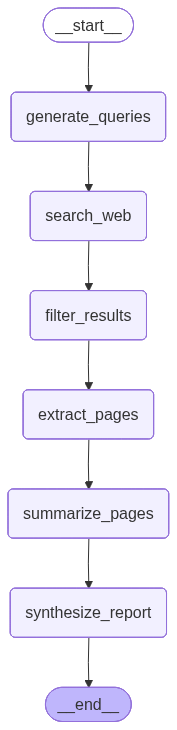

In [41]:
research_graph

### Run live research on a real topic

In [43]:
TOPIC = input("Enter a research topic: ").strip()

initial_state = {
    "topic": TOPIC,
    "tavily_topic": "",
    "sub_queries": [],
    "search_rows": [],
    "filtered_rows": [],
    "extracted_rows": [],
    "page_summaries": [],
    "final_report": {},
    "report_markdown": ""
}

current_state = initial_state.copy()

for chunk in research_graph.stream(
    initial_state,
    stream_mode=["updates", "custom"],
    version="v2"
):
    if chunk["type"] == "custom":
        print(f"[THINKING] {chunk['data']['message']}")
        
    elif chunk["type"] == "updates":
        for node_name, data in chunk["data"].items():
            # Check if data is a dictionary before calling .keys() or updating state
            if isinstance(data, dict):
                print(f"[DONE] {node_name}: {list(data.keys())}")
                current_state.update(data)
            else:
                # Catch-all for when data is None or empty (e.g., hitting the END node)
                print(f"[DONE] {node_name}: No state updates")

[THINKING] Planning search queries...
[THINKING] Built 4 search queries.
[DONE] generate_queries: ['tavily_topic', 'sub_queries']
[THINKING] Searching the web...
[THINKING] Running query: Top AI predictions and trends for 2025
[THINKING] Running query: Expected impact of AI on industries by 2025
[THINKING] Running query: Key AI technological advancements and breakthroughs 2025
[THINKING] Running query: Societal and ethical implications of AI in 2025
[THINKING] Collected 20 candidate results.
[DONE] search_web: No state updates


KeyError: 'search_rows'